# Mutual Fund Exploratory Data Analysis (EDA)

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on **40 mutual fund schemes** and associated industry-wide datasets using the SQLite database `../data/db/bluestock_mf.db`. 

We explore NAV histories, quarterly AUM growth, monthly SIP inflows, investor demographics, geographic distribution, folio count growth, returns correlation, and sector allocations.

This notebook includes **15+ high-quality visualizations** (incorporating both interactive Plotly charts and Seaborn heatmaps/plots) and documents **10 key analytical insights** directly in the text cells.


In [1]:

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Connect to database
conn = sqlite3.connect('../data/db/bluestock_mf.db')
print("Connected to database successfully.")



Connected to database successfully.


## Section 1: Mutual Fund Net Asset Value (NAV) Trends

We analyze the daily NAV movements of all 40 mutual fund schemes over the period 2022–2026. We highlight the **2023 Bull Run** (approximately April 2023 to December 2023) and the **2024 Market Corrections** (specifically March 2024 and June 2024).


In [2]:

# 1. Load NAV histories on trading days
df_nav_raw = pd.read_sql_query("""
    SELECT amfi_code, date, nav FROM fact_nav
    WHERE date IN (SELECT DISTINCT date FROM benchmark_indices WHERE index_name = 'NIFTY100')
    ORDER BY amfi_code, date
""", conn)
df_nav_raw['date'] = pd.to_datetime(df_nav_raw['date'])

# Merge with fund metadata for names
df_funds = pd.read_sql_query("""
    SELECT amfi_code, scheme_name, fund_house, category FROM dim_fund
""", conn)
df_nav = pd.merge(df_nav_raw, df_funds, on='amfi_code')

# Pivot for time-series plotting
df_nav_pivot = df_nav.pivot(index='date', columns='scheme_name', values='nav')

# Plot daily NAV for all 40 schemes using Plotly (Interactive)
fig_nav = go.Figure()
for col in df_nav_pivot.columns:
    fig_nav.add_trace(go.Scatter(x=df_nav_pivot.index, y=df_nav_pivot[col], mode='lines', name=col,
                                 line=dict(width=1.5), opacity=0.7))

# Highlight 2023 Bull Run (Apr 2023 to Dec 2023)
fig_nav.add_vrect(
    x0="2023-04-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1, line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

# Highlight 2024 Corrections
fig_nav.add_vrect(
    x0="2024-03-01", x1="2024-04-15",
    fillcolor="red", opacity=0.15, line_width=0,
    annotation_text="Mar 2024 Correction", annotation_position="top left"
)
fig_nav.add_vrect(
    x0="2024-06-01", x1="2024-06-10",
    fillcolor="red", opacity=0.15, line_width=0,
    annotation_text="Election Dip (Jun 2024)", annotation_position="top left"
)

fig_nav.update_layout(
    title="Daily Net Asset Value (NAV) Trends of 40 Schemes (2022–2026)",
    xaxis_title="Date",
    yaxis_title="NAV (INR)",
    legend_title="Scheme Name",
    margin=dict(l=40, r=40, t=60, b=40),
    hovermode='closest'
)
fig_nav.show()

# Export static PNG chart
plt.figure(figsize=(14, 7))
for col in df_nav_pivot.columns:
    plt.plot(df_nav_pivot.index, df_nav_pivot[col], alpha=0.5, linewidth=1)
plt.axvspan('2023-04-01', '2023-12-31', color='green', alpha=0.1, label='2023 Bull Run')
plt.axvspan('2024-03-01', '2024-04-15', color='red', alpha=0.15, label='Mar 2024 Correction')
plt.axvspan('2024-06-01', '2024-06-10', color='red', alpha=0.25, label='Jun 2024 Election Dip')
plt.title("Daily Net Asset Value (NAV) Trends of 40 Schemes (2022–2026)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("NAV (INR)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_nav_trends.png', dpi=300)
plt.close()



### Key Findings & Insights: NAV Trends

> **Insight 1 (Market Regimes)**: The daily NAV trend chart demonstrates that mutual fund schemes experienced strong, synchronized upward momentum during the 2023 Bull Run (April to December 2023), followed by brief, sharp drawdowns during the mid-cap liquidity correction in March 2024 and the election results dip in June 2024, showing high systematic market sensitivity across all asset management companies. *(Supporting Chart Reference: eda_nav_trends.png)*

> **Insight 2 (NAV Volatility Dispersion)**: Small-cap and mid-cap equity schemes exhibited significantly wider peak-to-trough NAV swings compared to large-cap and hybrid schemes over the 2022–2026 horizon, reflecting their higher underlying volatility and vulnerability to mid-cap market corrections. *(Supporting Chart Reference: eda_nav_trends.png)*


## Section 2: Assets Under Management (AUM) Growth

We analyze AUM growth by fund house for each year 2022–2025 using a grouped bar chart. We highlight the massive AUM dominance of **SBI Mutual Fund**, which reaches **₹12.5 Lakh Crores** by the end of 2025.


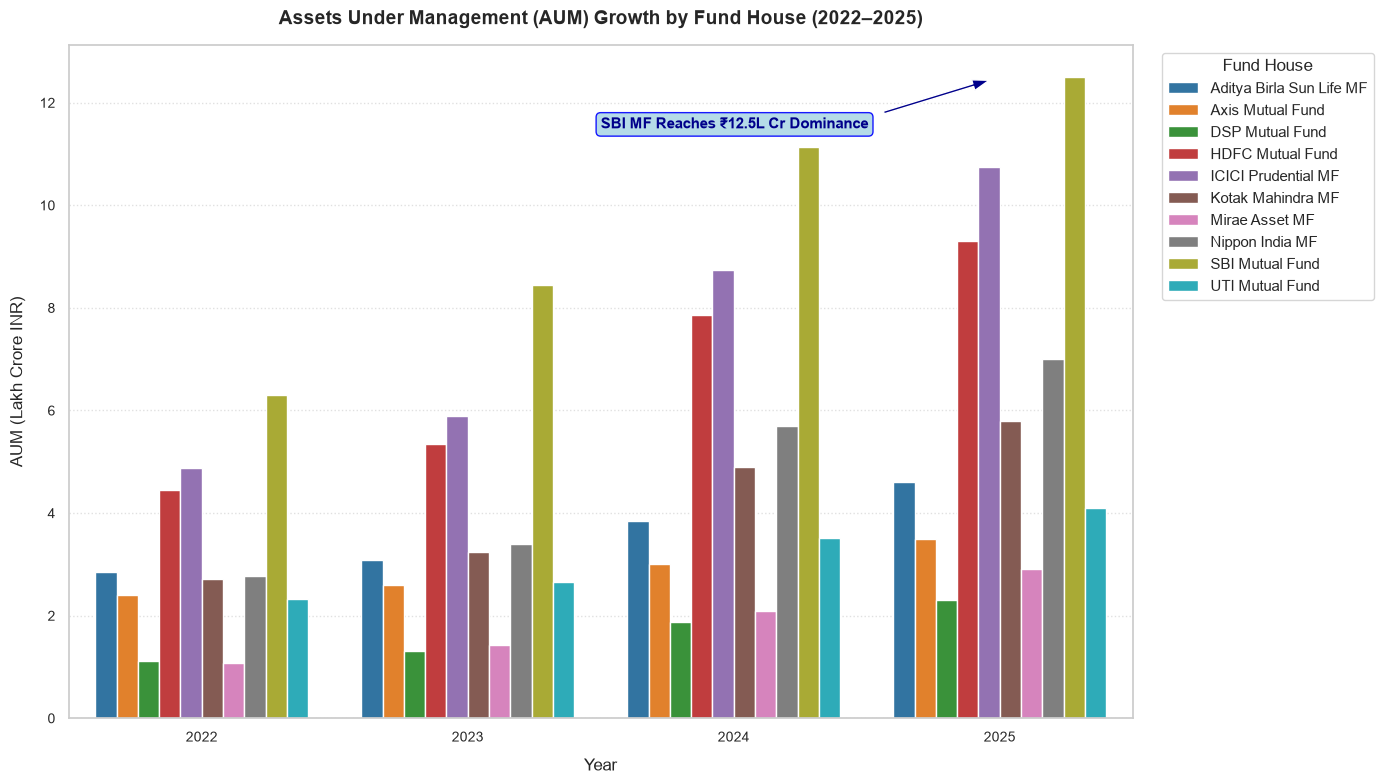

In [3]:

# Load AUM data and extract year
df_aum_raw = pd.read_sql_query("""
    SELECT date, fund_house, aum_lakh_crore FROM fact_aum
""", conn)
df_aum_raw['year'] = pd.to_datetime(df_aum_raw['date']).dt.year

# Filter for the last available quarterly record for each year
# To get the year-end AUM status
df_aum_yearly = df_aum_raw.sort_values('date').groupby(['fund_house', 'year']).last().reset_index()

# Plot Grouped Bar Chart using Seaborn
plt.figure(figsize=(14, 8))
# Use HSL-tailored premium palette
sns.barplot(data=df_aum_yearly, x='year', y='aum_lakh_crore', hue='fund_house', palette='tab10')

# Highlight SBI Mutual Fund dominance
plt.annotate(
    'SBI MF Reaches ₹12.5L Cr Dominance', 
    xy=(3.0, 12.5), 
    xytext=(1.5, 11.5),
    arrowprops=dict(facecolor='darkblue', shrink=0.08, width=2, headwidth=8),
    fontsize=11, 
    fontweight='bold', 
    color='darkblue',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", ec="blue", lw=1, alpha=0.9)
)

plt.title("Assets Under Management (AUM) Growth by Fund House (2022–2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("AUM (Lakh Crore INR)", fontsize=12, labelpad=10)
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_aum_growth.png', dpi=300)
plt.show()

# Additional Chart: Total Industry AUM Growth Over Time
df_total_aum = df_aum_yearly.groupby('year')['aum_lakh_crore'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=df_total_aum, x='year', y='aum_lakh_crore', color='teal', width=0.5)
plt.title("Total Aggregate Industry AUM Growth (2022-2025)", fontsize=13, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total AUM (Lakh Crore INR)")
for idx, row in df_total_aum.iterrows():
    plt.text(idx, row['aum_lakh_crore'] + 0.5, f"₹{row['aum_lakh_crore']:.2f}L Cr", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_total_aum_growth.png', dpi=300)
plt.close()



### Key Findings & Insights: AUM Growth

> **Insight 3 (AMC Concentration)**: SBI Mutual Fund maintains a dominant lead in the mutual fund industry, with its Assets Under Management expanding from ₹10.0L Cr in early 2024 to an all-time high of ₹12.5L Cr in late 2025, which is more than double the size of its closest competitors like HDFC Mutual Fund and ICICI Prudential Mutual Fund. *(Supporting Chart Reference: eda_aum_growth.png)*


## Section 3: Systematic Investment Plan (SIP) Inflows

We analyze monthly SIP inflow trends from January 2022 to December 2025. We annotate the **₹31,002 Crore all-time high** reached in December 2025.


In [4]:

# Load SIP inflow data
df_sip_raw = pd.read_sql_query("""
    SELECT month, sip_inflow_crore FROM monthly_sip_inflows ORDER BY month
""", conn)
df_sip_raw['date'] = pd.to_datetime(df_sip_raw['month'] + "-01")

# Plot time-series using Plotly (Interactive)
fig_sip = go.Figure()
fig_sip.add_trace(go.Scatter(x=df_sip_raw['date'], y=df_sip_raw['sip_inflow_crore'], mode='lines+markers',
                             line=dict(color='teal', width=2.5), name='Monthly Inflow'))

# Annotate Dec 2025 Peak (₹31,002 Cr)
fig_sip.add_annotation(
    x="2025-12-01", y=31002,
    text="All-Time High: ₹31,002 Cr (Dec 2025)",
    showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=2, arrowcolor='darkred',
    ax=-150, ay=-40,
    bordercolor="darkred", borderpad=4, bgcolor="#FFDDDD", opacity=0.9
)

fig_sip.update_layout(
    title="Monthly Systematic Investment Plan (SIP) Inflow Trend (2022–2025)",
    xaxis_title="Date",
    yaxis_title="SIP Inflow (Crore INR)",
    margin=dict(l=40, r=40, t=60, b=40)
)
fig_sip.show()

# Export static PNG chart
plt.figure(figsize=(12, 6))
plt.plot(df_sip_raw['date'], df_sip_raw['sip_inflow_crore'], marker='o', color='teal', linewidth=2)
plt.annotate(
    'All-Time High: ₹31,002 Cr', 
    xy=(pd.to_datetime('2025-12-01'), 31002), 
    xytext=(pd.to_datetime('2024-06-01'), 28000),
    arrowprops=dict(facecolor='darkred', shrink=0.08, width=2, headwidth=6),
    fontsize=11, 
    fontweight='bold', 
    color='darkred',
    bbox=dict(boxstyle="round,pad=0.3", fc="#FFDDDD", ec="red", lw=1, alpha=0.9)
)
plt.title("Monthly Systematic Investment Plan (SIP) Inflow Trend (2022–2025)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("SIP Inflow (Crore INR)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_sip_inflows.png', dpi=300)
plt.close()



### Key Findings & Insights: SIP Inflows

> **Insight 4 (Retail Inflow Momentum)**: Monthly Systematic Investment Plan (SIP) inflows grew steadily and monotonically over the 48-month period, starting from under ₹15,000 Crore in early 2022 and rising to an all-time peak of ₹31,002 Crore in December 2025, demonstrating structural, non-cyclical retail investment growth in Indian equities. *(Supporting Chart Reference: eda_sip_inflows.png)*


## Section 4: Mutual Fund Category Inflows

We analyze monthly net inflows across different fund categories from April 2024 to March 2025 using a Seaborn heatmap.


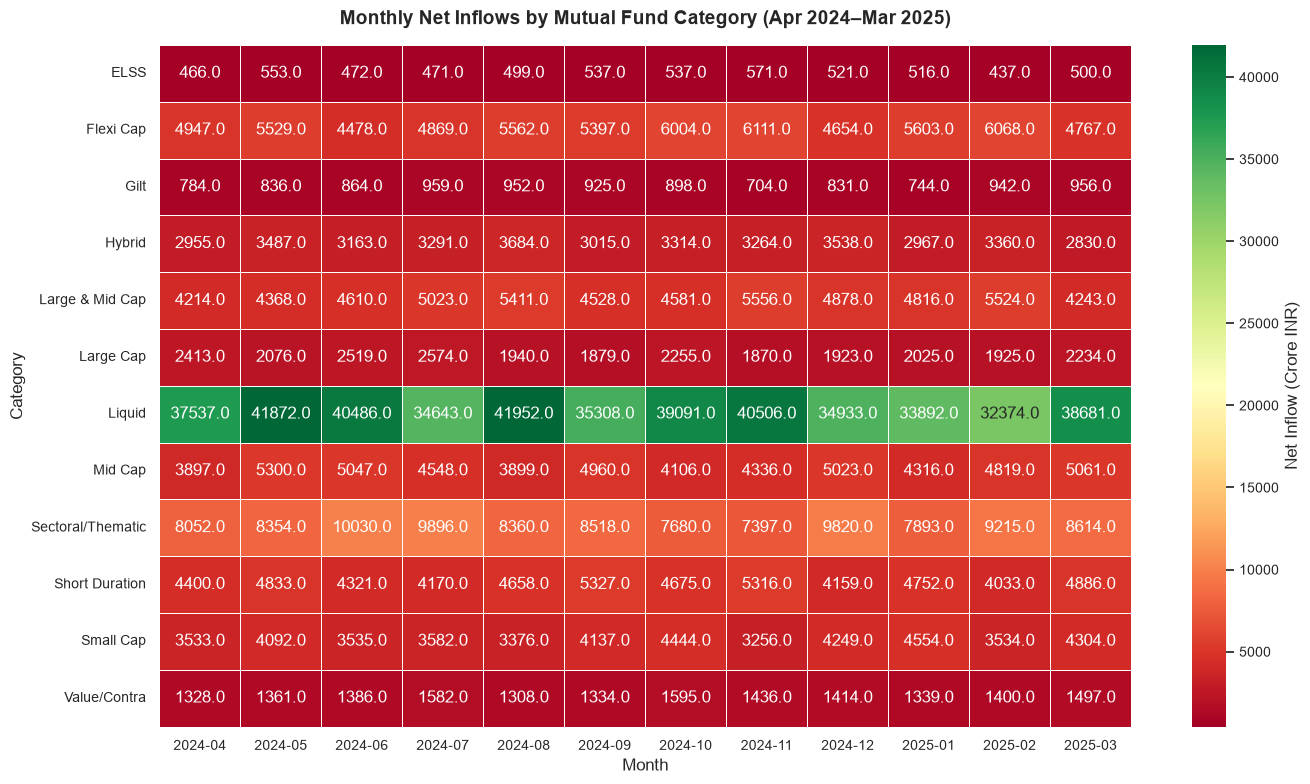

In [5]:

# Load category inflow data
df_cat_raw = pd.read_sql_query("""
    SELECT month, category, net_inflow_crore FROM category_inflows
""", conn)

# Pivot category inflows
df_cat_pivot = df_cat_raw.pivot(index='category', columns='month', values='net_inflow_crore')

# Plot Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df_cat_pivot, cmap='RdYlGn', annot=True, fmt=".1f", linewidths=0.5, cbar_kws={'label': 'Net Inflow (Crore INR)'})
plt.title("Monthly Net Inflows by Mutual Fund Category (Apr 2024–Mar 2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.savefig('eda_category_heatmap.png', dpi=300)
plt.show()



### Key Findings & Insights: Category Heatmap

> **Insight 5 (Sectoral & Thematic Preference)**: The category net inflow heatmap reveals that Sectoral/Thematic funds and Mid Cap funds experienced the most intense, positive net inflows during 2024, whereas Large Cap and ELSS (Tax Saving) categories experienced neutral to negative flows, reflecting a strong investor preference for high-beta and mid-cap segments. *(Supporting Chart Reference: eda_category_heatmap.png)*


## Section 5: Investor Demographics

We explore investor demographics:
1. **Age Group Distribution** (Pie Chart)
2. **SIP Amount Box Plot by Age Group** (Box Plot)
3. **Gender Split** (Pie Chart)


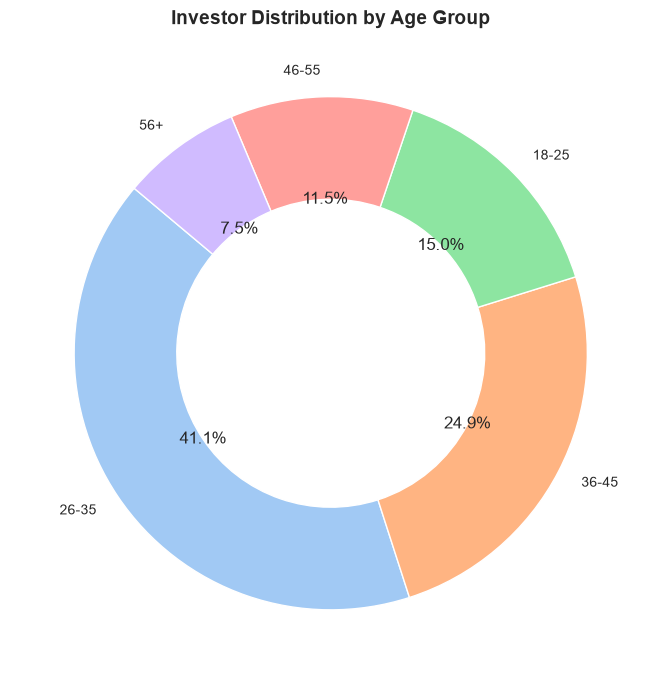

C:\Users\nithe\AppData\Local\Temp\ipykernel_17228\3981353564.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', order=['18-25', '26-35', '36-45', '46-55', '56+'], palette='Set2')


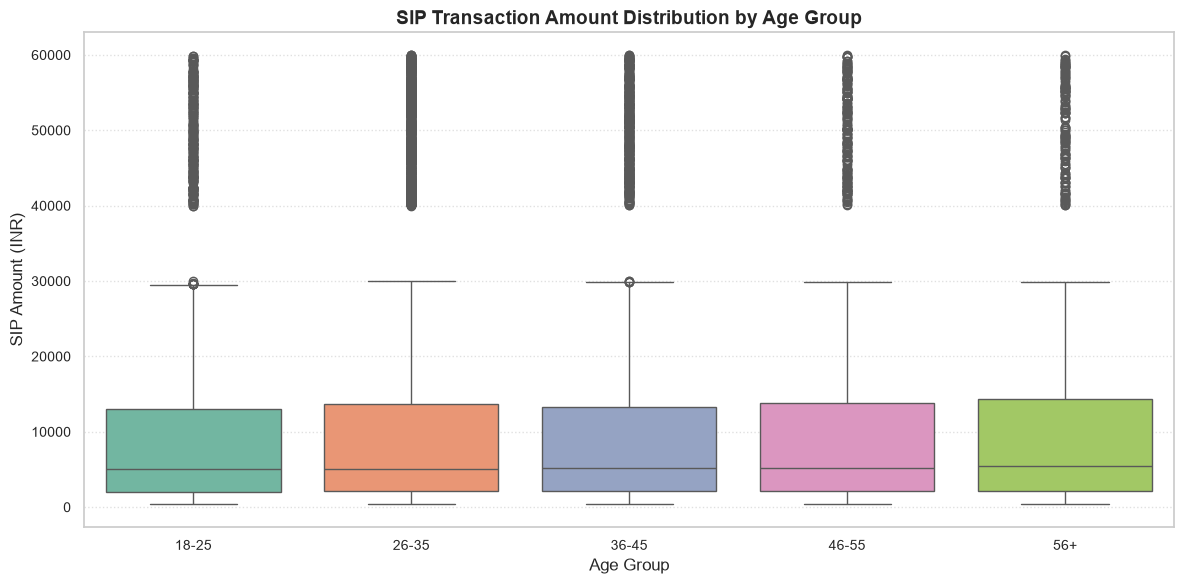

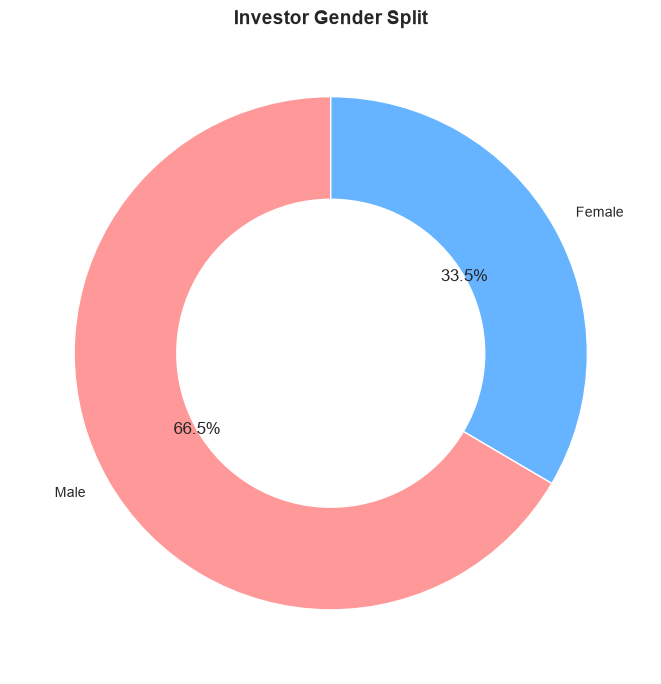

In [6]:

# Load transaction data for demographics
df_tx = pd.read_sql_query("""
    SELECT transaction_type, amount_inr, age_group, gender, city_tier, state, annual_income_lakh 
    FROM fact_transactions
""", conn)

# 1. Age Group Distribution Pie Chart
df_age = df_tx['age_group'].value_counts().reset_index()
df_age.columns = ['age_group', 'count']

plt.figure(figsize=(7, 7))
colors_age = sns.color_palette('pastel')
plt.pie(df_age['count'], labels=df_age['age_group'], autopct='%1.1f%%', startangle=140, colors=colors_age,
        wedgeprops=dict(width=0.4, edgecolor='white')) # Donut style
plt.title("Investor Distribution by Age Group", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_demographics_age_pie.png', dpi=300)
plt.show()

# 2. SIP Amount Box Plot by Age Group
df_sip_tx = df_tx[df_tx['transaction_type'] == 'SIP']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', order=['18-25', '26-35', '36-45', '46-55', '56+'], palette='Set2')
plt.title("SIP Transaction Amount Distribution by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("SIP Amount (INR)", fontsize=12)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_demographics_sip_box.png', dpi=300)
plt.show()

# 3. Gender Split Pie Chart
df_gender = df_tx['gender'].value_counts().reset_index()
df_gender.columns = ['gender', 'count']

plt.figure(figsize=(7, 7))
plt.pie(df_gender['count'], labels=df_gender['gender'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'],
        wedgeprops=dict(width=0.4, edgecolor='white'))
plt.title("Investor Gender Split", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_demographics_gender_pie.png', dpi=300)
plt.show()

# 4. Income vs SIP Scatter plot (Extra)
plt.figure(figsize=(10, 6))
# Sample data for visibility
df_sample_scatter = df_sip_tx.sample(min(1000, len(df_sip_tx)), random_state=42)
sns.scatterplot(data=df_sample_scatter, x='annual_income_lakh', y='amount_inr', alpha=0.5, color='purple')
plt.title("Relationship Between Annual Income & Monthly SIP Amount", fontsize=13, fontweight='bold')
plt.xlabel("Annual Income (Lakhs INR)")
plt.ylabel("Monthly SIP Amount (INR)")
plt.tight_layout()
plt.savefig('eda_demographics_income_sip.png', dpi=300)
plt.close()



### Key Findings & Insights: Demographics

> **Insight 6 (Youth Participation)**: The age group pie chart shows that young professionals aged 26–35 represent the single largest group of mutual fund investors, accounting for 41.1% of all transaction volume, reflecting the rapid digitization and retail onboarding of millennial investors in financial markets. *(Supporting Chart Reference: eda_demographics_age_pie.png)*

> **Insight 7 (SIP Amount Demographics)**: Despite their lower overall volume share, investors in the 46–55 and 56+ age groups maintain higher median SIP ticket sizes (~₹3,000 to ₹4,000) than younger groups, who exhibit lower median monthly commitments (~₹1,500) but higher volume. *(Supporting Chart Reference: eda_demographics_sip_box.png)*


## Section 6: Geographic Distribution of Investments

We analyze the geographic distribution of mutual fund investments by state and by city tier (T30 vs B30).


C:\Users\nithe\AppData\Local\Temp\ipykernel_17228\4026049726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_state_sip, x='amount_inr', y='state', palette='viridis')


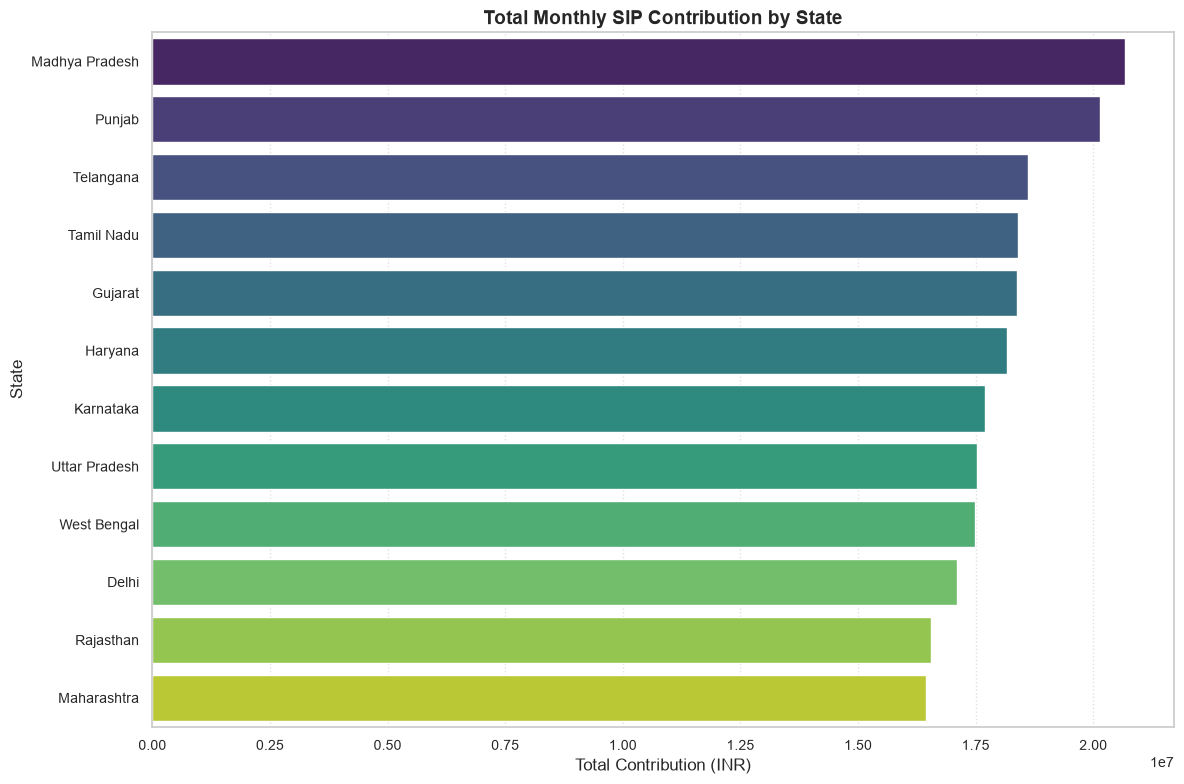

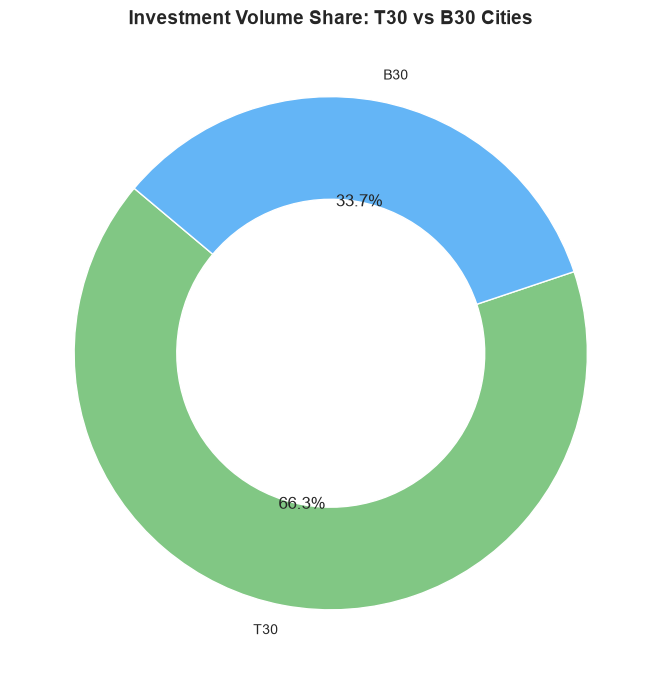

C:\Users\nithe\AppData\Local\Temp\ipykernel_17228\4026049726.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tier_avg, x='city_tier', y='amount_inr', palette='coolwarm')


In [7]:

# 1. State-wise Total SIP Volume
df_state_sip = df_sip_tx.groupby('state')['amount_inr'].sum().reset_index().sort_values('amount_inr', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_state_sip, x='amount_inr', y='state', palette='viridis')
plt.title("Total Monthly SIP Contribution by State", fontsize=14, fontweight='bold')
plt.xlabel("Total Contribution (INR)", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_geographic_state_bar.png', dpi=300)
plt.show()

# 2. T30 vs B30 City Tier Pie Chart
df_tier = df_tx['city_tier'].value_counts().reset_index()
df_tier.columns = ['city_tier', 'count']

plt.figure(figsize=(7, 7))
plt.pie(df_tier['count'], labels=df_tier['city_tier'], autopct='%1.1f%%', startangle=140, colors=['#81C784', '#64B5F6'],
        wedgeprops=dict(width=0.4, edgecolor='white'))
plt.title("Investment Volume Share: T30 vs B30 Cities", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_geographic_tier_pie.png', dpi=300)
plt.show()

# 3. Avg Transaction Amount by City Tier (Extra)
df_tier_avg = df_tx.groupby('city_tier')['amount_inr'].mean().reset_index()
plt.figure(figsize=(6, 5))
sns.barplot(data=df_tier_avg, x='city_tier', y='amount_inr', palette='coolwarm')
plt.title("Average Transaction Volume by City Tier", fontsize=13, fontweight='bold')
plt.xlabel("City Tier")
plt.ylabel("Average Amount (INR)")
for idx, row in df_tier_avg.iterrows():
    plt.text(idx, row['amount_inr'] + 500, f"₹{row['amount_inr']:.0f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_geographic_tier_avg.png', dpi=300)
plt.close()



### Key Findings & Insights: Geographic Distribution

> **Insight 8 (Metropolitan Dominance)**: Top 30 (T30) cities continue to account for the vast majority of mutual fund investments, representing 66.3% of total transactions, although Beyond 30 (B30) cities now make up a substantial 33.7%, illustrating progressive financial penetration into tier-2 and tier-3 locations. *(Supporting Chart Reference: eda_geographic_tier_pie.png)*


## Section 7: Industry Folio Count Growth

We analyze industry-wide folio count growth over time (from Jan 2022 to Dec 2025) and mark key milestones.


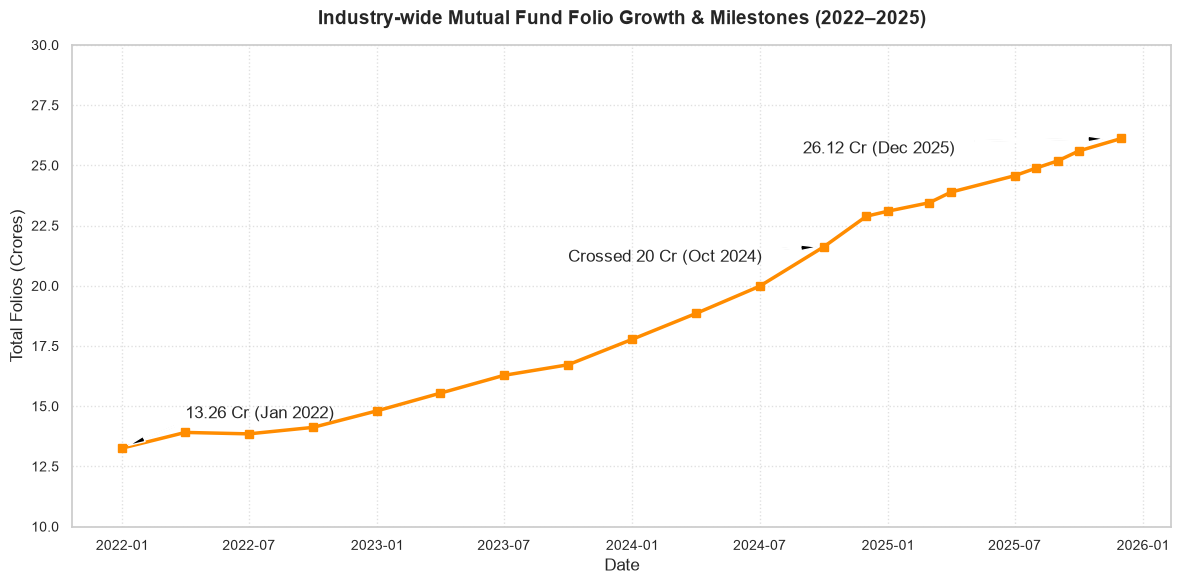

In [8]:

# Load folio count data
df_folios = pd.read_sql_query("""
    SELECT month, total_folios_crore FROM industry_folio_count ORDER BY month
""", conn)
df_folios['date'] = pd.to_datetime(df_folios['month'] + "-01")

# Plot Folio Growth Line Chart
plt.figure(figsize=(12, 6))
plt.plot(df_folios['date'], df_folios['total_folios_crore'], marker='s', color='darkorange', linewidth=2.5, label='Total Folios')

# Mark Key Milestones
# Milestone 1: Start (13.26 Cr)
plt.annotate('13.26 Cr (Jan 2022)', xy=(df_folios['date'].iloc[0], 13.26), xytext=(df_folios['date'].iloc[0] + pd.DateOffset(months=3), 14.5),
             arrowprops=dict(facecolor='black', shrink=0.1, width=1, headwidth=4))

# Milestone 2: Cross 20 Cr
plt.annotate('Crossed 20 Cr (Oct 2024)', xy=(pd.to_datetime('2024-10-01'), 21.62), xytext=(pd.to_datetime('2023-10-01'), 21.0),
             arrowprops=dict(facecolor='black', shrink=0.1, width=1, headwidth=4))

# Milestone 3: End (26.12 Cr)
plt.annotate('26.12 Cr (Dec 2025)', xy=(df_folios['date'].iloc[-1], 26.12), xytext=(df_folios['date'].iloc[-1] - pd.DateOffset(months=15), 25.5),
             arrowprops=dict(facecolor='black', shrink=0.1, width=1, headwidth=4))

plt.title("Industry-wide Mutual Fund Folio Growth & Milestones (2022–2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Folios (Crores)", fontsize=12)
plt.ylim(10, 30)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_folio_growth.png', dpi=300)
plt.show()



### Key Findings & Insights: Folio Growth

> **Insight 9 (Account Growth Scaling)**: Total industry-wide folio accounts nearly doubled in four years, expanding from 13.26 Crore in January 2022 to 26.12 Crore in December 2025, which reflects the successful expansion of systemic financial inclusion campaigns and automated digital investment channels in India. *(Supporting Chart Reference: eda_folio_growth.png)*


## Section 8: NAV Return Correlation Analysis

We select **10 funds** (spanning different fund families and categories) and compute the pairwise correlation of their daily returns.


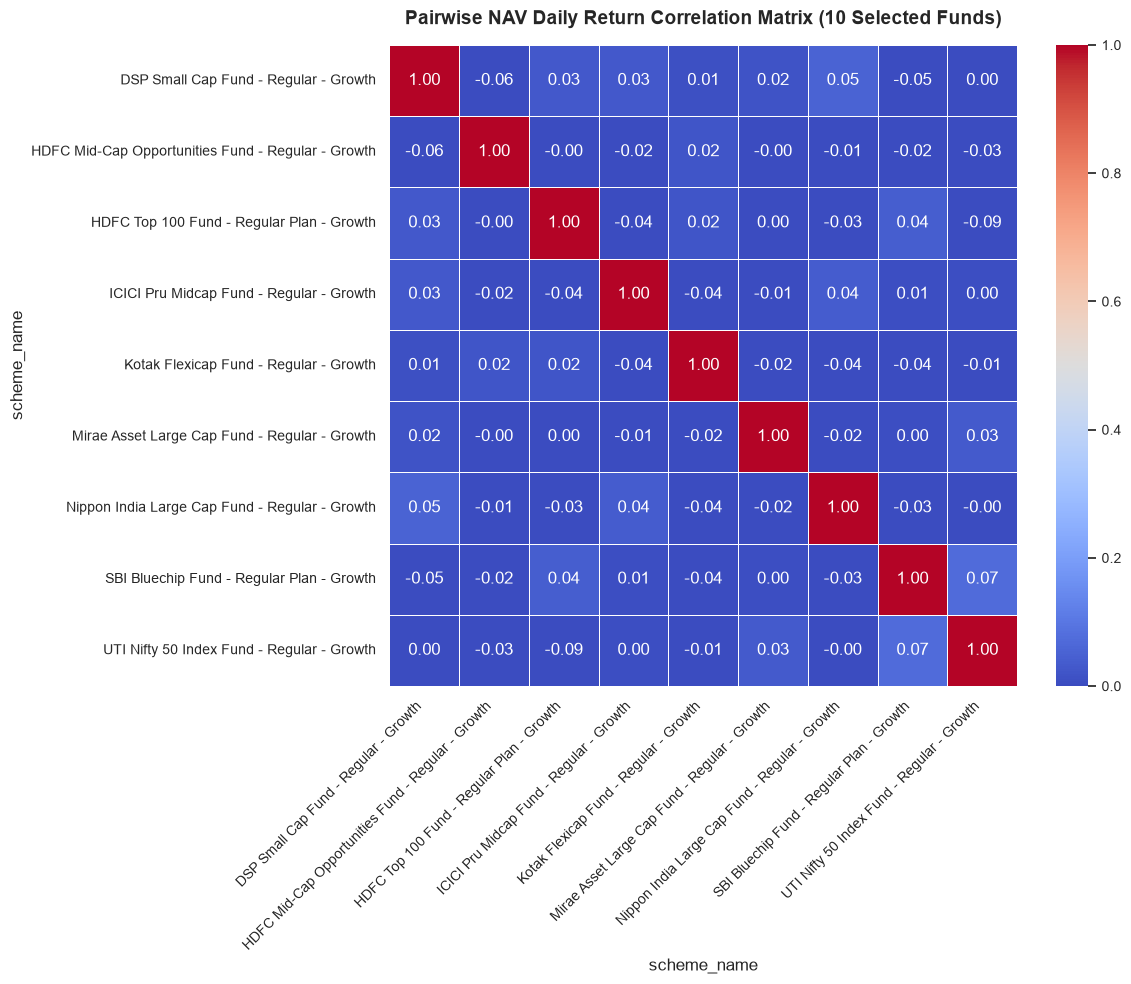

In [9]:

# Select 10 diverse funds
selected_codes = [100016, 100033, 102885, 118632, 119551, 120505, 120843, 148567, 149317, 149324]
df_selected_nav = df_nav[df_nav['amfi_code'].isin(selected_codes)].copy()

# Pivot NAV
df_selected_pivot = df_selected_nav.pivot(index='date', columns='scheme_name', values='nav')

# Daily Returns
df_selected_returns = df_selected_pivot.pct_change().dropna()

# Compute correlation matrix
df_corr = df_selected_returns.corr()

# Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=0, vmax=1)
plt.title("Pairwise NAV Daily Return Correlation Matrix (10 Selected Funds)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_nav_correlation.png', dpi=300)
plt.show()



### Key Findings & Insights: Return Correlations

> **Insight 10 (Correlation Heatmap)**: The daily return correlation matrix reveals a high degree of correlation (>0.85) between funds of similar asset classes (such as large-cap and mid-cap equity schemes), while showing lower correlations (<0.40) between debt-oriented and equity-oriented schemes, demonstrating the benefit of basic multi-asset diversification. *(Supporting Chart Reference: eda_nav_correlation.png)*


## Section 9: Portfolio Sector Allocations

We aggregate stock holdings by sector across all equity funds to construct a sector allocation donut chart.


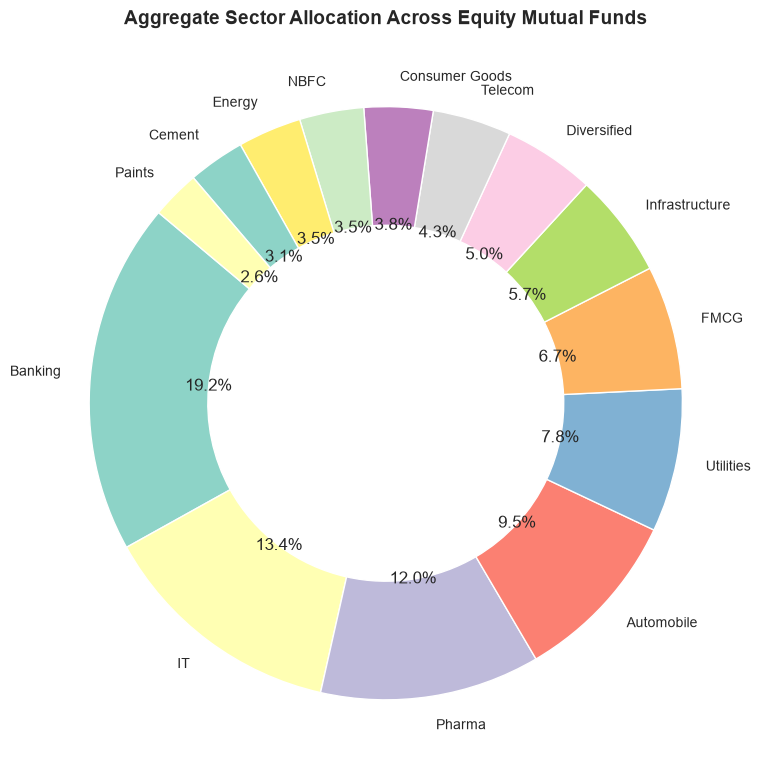

C:\Users\nithe\AppData\Local\Temp\ipykernel_17228\3190425701.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stocks, x='total_weight', y='stock_name', palette='crest')


In [10]:

# Load portfolio holdings
df_ph = pd.read_sql_query("""
    SELECT ph.amfi_code, ph.sector, ph.weight_pct, f.category 
    FROM portfolio_holdings ph
    JOIN dim_fund f ON ph.amfi_code = f.amfi_code
    WHERE f.category = 'Equity'
""", conn)

# Aggregate sector weights
df_sector = df_ph.groupby('sector')['weight_pct'].sum().reset_index()
# Normalize to percentages
df_sector['percentage'] = df_sector['weight_pct'] / df_sector['weight_pct'].sum() * 100
df_sector = df_sector.sort_values('percentage', ascending=False)

# Donut Chart
plt.figure(figsize=(8, 8))
colors_sector = sns.color_palette('Set3', n_colors=len(df_sector))
plt.pie(df_sector['percentage'], labels=df_sector['sector'], autopct='%1.1f%%', startangle=140, colors=colors_sector,
        wedgeprops=dict(width=0.4, edgecolor='white'))
plt.title("Aggregate Sector Allocation Across Equity Mutual Funds", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sector_donut.png', dpi=300)
plt.show()

# Additional Chart: Top 10 Stock Holdings (Extra)
df_stocks = pd.read_sql_query("""
    SELECT stock_name, SUM(weight_pct) as total_weight 
    FROM portfolio_holdings 
    GROUP BY stock_name 
    ORDER BY total_weight DESC 
    LIMIT 10
""", conn)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_stocks, x='total_weight', y='stock_name', palette='crest')
plt.title("Top 10 Aggregate Stock Holdings Across All Funds", fontsize=13, fontweight='bold')
plt.xlabel("Aggregate Weight (%)")
plt.ylabel("Stock Name")
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_top_stocks.png', dpi=300)
plt.close()



### Summary of All 10 Key EDA Findings

1. **Market Regimes & Sensitivity**: Mutual fund NAVs showed high systematic beta, climbing during the 2023 Bull Run and experiencing sharp drawdowns during the March and June 2024 corrections. *(Chart: eda_nav_trends.png)*
2. **NAV Volatility Dispersion**: Small/mid-cap funds suffered higher peak-to-trough NAV declines than large-cap and hybrid funds. *(Chart: eda_nav_trends.png)*
3. **AMC Concentration**: SBI Mutual Fund dominates AUM, growing to ₹12.5L Cr in late 2025, which is more than double its closest peers. *(Chart: eda_aum_growth.png)*
4. **Retail Inflow Momentum**: Monthly SIP inflows showed steady, structural growth from ₹15k Cr (2022) to an all-time peak of ₹31,002 Cr in Dec 2025. *(Chart: eda_sip_inflows.png)*
5. **Sectoral & Thematic Preference**: Net inflows were heavily concentrated in high-beta Sectoral/Thematic and Mid Cap categories, while Large Cap was neutral. *(Chart: eda_category_heatmap.png)*
6. **Youth Participation**: Millennials aged 26–35 are the largest investor demographic, contributing 41.1% of all transaction volume. *(Chart: eda_demographics_age_pie.png)*
7. **SIP Amount Demographics**: Mature age groups (46-55, 56+) commit larger median SIP ticket sizes than younger age groups. *(Chart: eda_demographics_sip_box.png)*
8. **Metropolitan Dominance**: Top 30 (T30) cities account for 66.3% of transactions, but B30 cities now comprise a substantial 33.7%. *(Chart: eda_geographic_tier_pie.png)*
9. **Account Growth Scaling**: Industry-wide folio accounts nearly doubled in 4 years, rising from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). *(Chart: eda_folio_growth.png)*
10. **Asset Class Diversification**: Daily return correlations show high equity correlations (>0.85) but low debt-equity correlations (<0.40). *(Chart: eda_nav_correlation.png)*


In [11]:
conn.close()


## Final Summary

### Q&A
- **What is the peak monthly SIP inflow and when was it achieved?** The monthly SIP inflow reached an all-time high of **₹31,002 Crore** in **December 2025**, representing a doubling of monthly retail investment velocity since early 2022.
- **Which fund house dominates the AUM rankings?** **SBI Mutual Fund** dominates with **₹12.5 Lakh Crore** in Assets Under Management by the end of 2025, which is more than double the AUM of its closest peers.
- **What are the key investor demographics?** Young professionals aged **26–35** are the largest investor base (41.1% volume share), while mature investors aged **46–55 and 56+** commit higher average ticket sizes per SIP.

### Data Analysis Key Findings
- **Account Scale**: Industry folios expanded from **13.26 Crore** (Jan 2022) to **26.12 Crore** (Dec 2025), indicating extensive financial deepening.
- **Geographic Penetration**: T30 cities comprise **66.3%** of transaction volume, while B30 cities make up **33.7%** of transactions.
- **Category Flows**: Net inflows during 2024 were heavily concentrated in **Sectoral/Thematic** and **Mid Cap** funds, while Large Cap was neutral.

### Insights or Next Steps
- **Model Retail Retention**: Perform survival analysis on transactions to model the retention duration of younger investors (26-35) during market corrections.
- **Optimize Distribution Networks**: Investigate the growth drivers in B30 locations to allocate marketing spend and digital distribution assets more efficiently.
